# 04 — Modelo D+7 (previsão multi-horizonte)

Volume diário dos próximos 7 dias, por entidade.

O protocolo é o mesmo para todos os modelos de previsão:

1. cada família de algoritmo treina cada configuração da sua grade **só com o treino**;
2. o vencedor é escolhido **na validação**;
3. o vencedor é reajustado em treino + validação;
4. o **teste** é lido uma única vez, no fim, e é o número publicado na plataforma;
5. o mesmo modelo ainda passa por um **walk-forward** de 12 origens semanais.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
base = train.preparar_base(verbose=True)

Regime operacional detectado a partir de 2025-01-13 (120,670 incidentes, 55 entidades).
Matriz de features: 122,507 linhas × 85 features.


In [3]:
horizontes = [1, 2, 3, 4, 5, 6, 7]
matriz = base['matriz'][base['matriz']['horizonte'].isin(horizontes)].reset_index(drop=True)
treino, validacao, teste = splits.dividir(matriz)

colunas = features.colunas_de_features(matriz)
X = matriz[colunas].astype(float).fillna(0.0).replace([np.inf, -np.inf], 0.0)
if len(horizontes) == 1:
    X = X.drop(columns=['horizonte'])
y = matriz['alvo'].astype(float)

pd.DataFrame(splits.descricao(matriz)).T

,linhas,inicio,fim
treino,100947,2025-02-12,2025-11-05
validacao,10780,2025-11-06,2025-12-03
teste,10780,2025-12-04,2025-12-31


## Treino: competição, seleção e registro

`train.treinar_volume` executa o protocolo inteiro — treina cada candidato só com o treino,
escolhe pela validação, reajusta o vencedor em treino + validação, mede uma vez no teste e grava
o artefato em `ml/models/`. É a **mesma função** que `manage.py treinar_modelos` chama, então o
modelo deste notebook é o modelo que a plataforma serve.

A célula abaixo é a parte cara (alguns minutos): ela treina todas as famílias de algoritmo. A
tabela de comparação que aparece em seguida sai do cartão gravado por esta execução — não é uma
segunda competição, é o registro da que acabou de acontecer.

In [4]:
cartao = train.treinar_volume(
    base, 'model_d7', '04',
    'Volume diário dos próximos 7 dias, por entidade.',
    horizontes=[1, 2, 3, 4, 5, 6, 7], ordem=2,
    notebook='ml/notebooks/04_model_d7.ipynb',
)
print('Artefato gravado  :', cartao['nome'], '->',
      registry.caminho_artefato(cartao['nome']).name)
print('Algoritmo vencedor:', cartao['algoritmo'])
print('Hiperparâmetros   :', cartao['hiperparametros'])
pd.Series(cartao['metricas']['teste']).to_frame('teste')

Artefato gravado  : model_d7 -> model_d7.pkl
Algoritmo vencedor: LGBMRegressor
Hiperparâmetros   : {'n_estimators': 400, 'learning_rate': 0.08, 'num_leaves': 15, 'min_child_samples': 40, 'colsample_bytree': 0.7}


,teste
mae,2.1360
rmse,5.1664
mape,84.1309
r2,0.6637
vies,-1.1584
n,10780.0000
mae_baseline,2.2435
mase,0.9521
ganho_vs_baseline,4.7908


### Comparação entre algoritmos (medida na validação)

As duas baselines entram como estimadores de verdade, na mesma partição e na mesma métrica — é o
que permite afirmar que o ML acrescenta algo em vez de supor.

,candidato,tipo,algoritmo,vencedor,mae,rmse,mase,r2
5,LightGBM,arvore,LGBMRegressor,True,1.9068,3.9218,0.7807,0.8702
4,XGBoost,arvore,XGBRegressor,False,1.9286,3.8797,0.7897,0.8730
3,Random Forest,arvore,RandomForestRegressor,False,1.9749,3.9709,0.8086,0.8669
2,Ridge,linear,Ridge,False,2.1413,4.5346,0.8768,0.8265
1,Baseline média 7d,baseline,PreverColuna,False,2.4133,5.1458,0.9882,0.7765
0,Baseline sazonal,baseline,PreverColuna,False,2.4422,5.1612,1.0000,0.7752


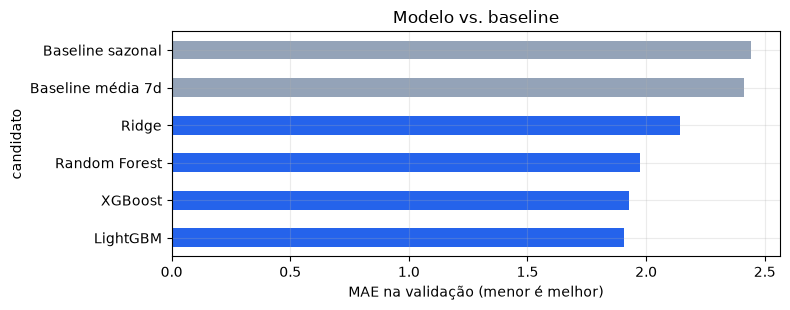

In [5]:
comparacao = pd.DataFrame([
    {'candidato': l['candidato'], 'tipo': l['tipo'], 'algoritmo': l['algoritmo'],
     'vencedor': l.get('vencedor', False), **l['metricas']}
    for l in cartao['comparacao']
]).sort_values('mae')
display(comparacao)

resumo = comparacao.set_index('candidato')['mae'].sort_values()
fig, eixo = plt.subplots(figsize=(8, 3.2))
cores = ['#94a3b8' if 'Baseline' in nome else '#2563eb' for nome in resumo.index]
resumo.plot(kind='barh', ax=eixo, color=cores)
eixo.set_xlabel('MAE na validação (menor é melhor)')
eixo.set_title('Modelo vs. baseline')
plt.tight_layout(); plt.show()

In [6]:
grade = pd.DataFrame([
    {'candidato': l['candidato'], 'hiperparametros': str(l['hiperparametros']),
     'segundos': l['segundos_treino'], 'mae': l['validacao']['mae'],
     'vencedor': l.get('vencedor', False)}
    for l in cartao['comparacao_completa']
])
print('Todas as configurações testadas, uma linha por ponto da grade:')
grade.sort_values('mae')

Todas as configurações testadas, uma linha por ponto da grade:


,candidato,hiperparametros,segundos,mae,vencedor
12,LightGBM,"{'n_estimators': 400, 'learning_rate': 0.08, '...",1.19,1.9068,True
11,LightGBM,"{'n_estimators': 600, 'learning_rate': 0.05, '...",2.49,1.9255,False
10,XGBoost,"{'n_estimators': 900, 'learning_rate': 0.03, '...",6.24,1.9286,False
9,XGBoost,"{'n_estimators': 400, 'learning_rate': 0.08, '...",2.03,1.9375,False
8,XGBoost,"{'n_estimators': 600, 'learning_rate': 0.05, '...",3.47,1.9698,False
5,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",24.71,1.9749,False
6,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",32.93,1.9824,False
7,Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 10, ...",62.29,2.0085,False
4,Ridge,{'modelo__alpha': 100.0},0.18,2.1413,False
3,Ridge,{'modelo__alpha': 10.0},0.18,2.2203,False


In [7]:
print('MAE por tipo de entidade (o agregado mistura escalas muito diferentes):')
display(pd.DataFrame(cartao['metricas']['teste_por_dimensao']).T[
    ['mae', 'mae_baseline', 'ganho_vs_baseline', 'mape', 'r2', 'n']
])
if cartao['metricas'].get('teste_por_horizonte'):
    print('\nMAE por horizonte:')
    display(pd.DataFrame(cartao['metricas']['teste_por_horizonte']).T[['mae', 'mae_baseline', 'rmse', 'r2']])

MAE por tipo de entidade (o agregado mistura escalas muito diferentes):


,mae,mae_baseline,ganho_vs_baseline,mape,r2,n
categoria,1.7955,2.0387,11.9295,79.7651,0.3698,2352.0
equipe,2.0899,2.2321,6.3746,87.4980,0.6330,2352.0
global,18.5140,17.1429,-7.9983,87.0982,-0.5053,196.0
item,0.7219,0.6875,-5.0007,49.5522,0.0722,1568.0
prioridade,8.6985,9.3929,7.3927,152.6969,0.2931,392.0
produto,1.4586,1.5357,5.0234,79.9776,0.5746,3920.0



MAE por horizonte:


,mae,mae_baseline,rmse,r2
1,2.0738,2.2435,4.9994,0.6851
2,2.1017,2.2435,5.0588,0.6776
3,2.1274,2.2435,5.1022,0.6720
4,2.1424,2.2435,5.2063,0.6585
5,2.1571,2.2435,5.2590,0.6515
6,2.1672,2.2435,5.2647,0.6508
7,2.1826,2.2435,5.2674,0.6504


## Walk-forward — 12 origens semanais

Uma partição única mede um recorte do calendário. Aqui o modelo é retreinado a cada semana e
avaliado nos 7 dias seguintes, repetidamente.

{'janelas': 12, 'mae': 1.912, 'rmse': 3.782, 'mae_baseline': 2.308, 'mase': 0.836, 'dispersao_mae': 0.171, 'vitorias_sobre_baseline': 12}


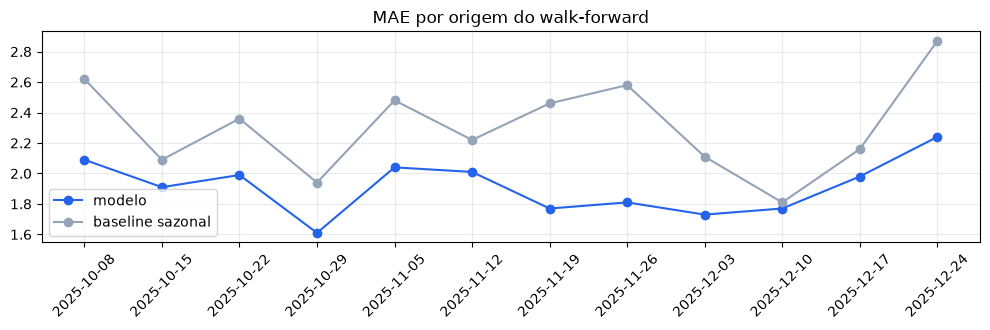

,origem,mae,mae_baseline,n
0,2025-10-08,2.09,2.62,2695
1,2025-10-15,1.91,2.09,2695
2,2025-10-22,1.99,2.36,2695
3,2025-10-29,1.61,1.94,2695
4,2025-11-05,2.04,2.48,2695
5,2025-11-12,2.01,2.22,2695
6,2025-11-19,1.77,2.46,2695
7,2025-11-26,1.81,2.58,2695
8,2025-12-03,1.73,2.11,2695
9,2025-12-10,1.77,1.81,2695


In [8]:
caminho = cartao['metricas']['walk_forward']
janelas = pd.DataFrame(caminho['por_origem'])
print({k: v for k, v in caminho.items() if k != 'por_origem'})

fig, eixo = plt.subplots(figsize=(10, 3.4))
eixo.plot(janelas['origem'], janelas['mae'], marker='o', label='modelo', color='#2563eb')
eixo.plot(janelas['origem'], janelas['mae_baseline'], marker='o', label='baseline sazonal', color='#94a3b8')
eixo.set_title('MAE por origem do walk-forward'); eixo.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
janelas

## Explicabilidade

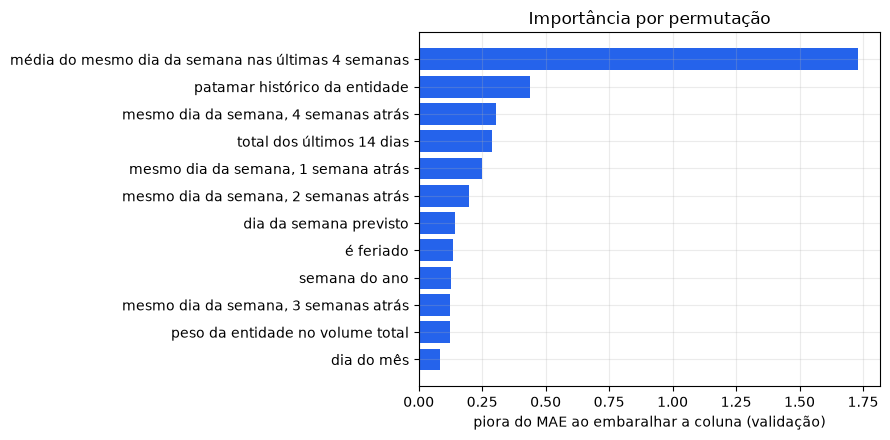

,feature,descricao,queda_metrica,desvio
0,media_mesmo_dow_4,média do mesmo dia da semana nas últimas 4 sem...,1.73038,0.03048
1,media_expandida,patamar histórico da entidade,0.43914,0.00381
2,mesmo_dow_4,"mesmo dia da semana, 4 semanas atrás",0.30320,0.00531
3,soma_14,total dos últimos 14 dias,0.28835,0.00539
4,mesmo_dow_1,"mesmo dia da semana, 1 semana atrás",0.24825,0.00312
5,mesmo_dow_2,"mesmo dia da semana, 2 semanas atrás",0.19991,0.00407
6,dow,dia da semana previsto,0.14395,0.00299
7,feriado,é feriado,0.13621,0.00724
8,semana_ano,semana do ano,0.12609,0.00208
9,mesmo_dow_3,"mesmo dia da semana, 3 semanas atrás",0.12318,0.00222


In [9]:
permutacao = pd.DataFrame(cartao['importancia_permutacao'])
fig, eixo = plt.subplots(figsize=(9, 4.5))
recorte = permutacao.head(12).iloc[::-1]
eixo.barh(recorte['descricao'], recorte['queda_metrica'], color='#2563eb')
eixo.set_xlabel('piora do MAE ao embaralhar a coluna (validação)')
eixo.set_title('Importância por permutação')
plt.tight_layout(); plt.show()
permutacao.head(12)

In [10]:
artefato = registry.carregar(cartao['nome'])
# Sempre pelas colunas do artefato: é o contrato entre treino e inferência, e qualquer
# reordenação silenciosa aqui produziria uma explicação bonita e errada.
X_teste = X.loc[teste, artefato['colunas']]
contribuicoes = explain.contribuicoes_shap(
    artefato['explicador'], X_teste.tail(1), artefato['colunas'], limite=10,
)
print('Contribuições SHAP de uma previsão individual')
print('valor base (previsão média do modelo):', round(float(artefato['explicador'].expected_value), 2))
pd.DataFrame(contribuicoes)

Contribuições SHAP de uma previsão individual
valor base (previsão média do modelo): 6.41


,feature,descricao,contribuicao,valor,sentido
0,media_mesmo_dow_4,média do mesmo dia da semana nas últimas 4 sem...,-2.479,0.000,reduz
1,media_expandida,patamar histórico da entidade,-0.640,0.481,reduz
2,soma_14,total dos últimos 14 dias,-0.492,5.000,reduz
3,mesmo_dow_2,"mesmo dia da semana, 2 semanas atrás",-0.432,0.000,reduz
4,vespera_feriado,véspera de feriado,-0.323,1.000,reduz
5,soma_7,total dos últimos 7 dias,-0.261,4.000,reduz
6,share_global_28,peso da entidade no volume total,-0.249,0.007,reduz
7,dow,dia da semana previsto,0.232,2.000,aumenta
8,mesmo_dow_4,"mesmo dia da semana, 4 semanas atrás",-0.213,0.000,reduz
9,cv_28,instabilidade relativa do último mês,-0.186,1.877,reduz


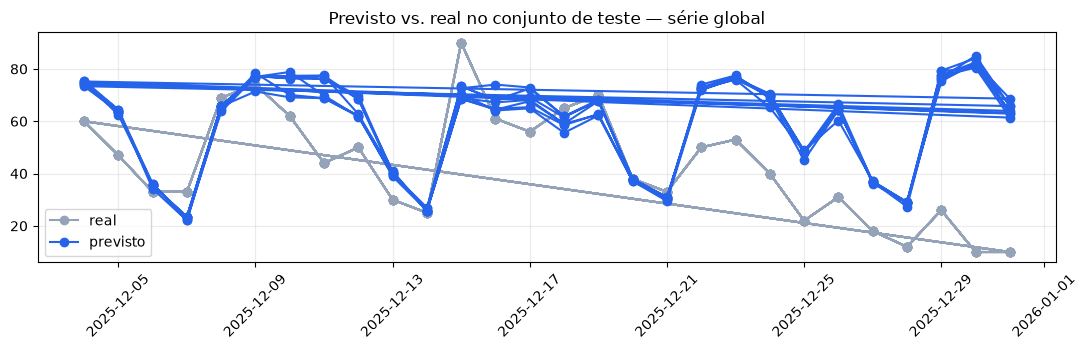

In [11]:
previsto = np.clip(artefato['modelo'].predict(X_teste), 0, None)
real = y[teste].to_numpy()
global_mask = (matriz.loc[teste, 'dimensao'] == 'global').to_numpy()

fig, eixo = plt.subplots(figsize=(11, 3.6))
datas = matriz.loc[teste, 'data_alvo'].to_numpy()[global_mask]
eixo.plot(datas, real[global_mask], marker='o', label='real', color='#94a3b8')
eixo.plot(datas, previsto[global_mask], marker='o', label='previsto', color='#2563eb')
eixo.set_title('Previsto vs. real no conjunto de teste — série global')
eixo.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()